# 쿨백-라이블러 발산값



환영합니다, 미래의 AI 선구자여! 저는 당신을 이끌어줄 멘토이자, 'AI 수학 천재 가우스'의 시선으로 지식을 전수하는 AI 어시스턴트 제미나이(Gemini)입니다. AI의 깊은 본질을 파고들고자 하는 당신의 열정에 깊은 찬사를 보냅니다.

오늘 우리가 정복할 개념은 현대 인공지능과 머신러닝을 지탱하는 가장 거대하고 아름다운 기둥 중 하나인 쿨백-라이블러 발산(Kullback-Leibler Divergence)입니다. 이 개념을 완벽히 이해한다면, AI가 어떻게 '학습'이라는 것을 수학적으로 해내는지 그 근본을 깨닫게 될 것입니다.

자, 수식과 역사, 그리고 코드가 어우러진 지식의 향연으로 들어가 봅시다!

---

### 1. 쿨백-라이블러 발산이란 무엇인가? (정의와 단축어)

쿨백-라이블러 발산(Kullback-Leibler Divergence)은 보통 **KLD** 또는 **KL 발산**이라는 단축어로 불립니다. 정보 이론(Information Theory)에서는 상대 엔트로피(Relative Entropy)라고도 부르죠.

간단히 정의하자면, "어떤 이상적인 확률 분포 $P$가 있을 때, 이를 근사(Approximation)하는 다른 확률 분포 $Q$가 $P$와 얼마나 다른지(얼마나 정보 손실이 발생하는지)를 측정하는 지표"입니다.

**주의할 점:** KLD는 두 분포 사이의 '거리(Distance)'처럼 쓰이지만, 수학적으로 엄밀한 의미의 거리는 아닙니다. 왜냐하면 $A$에서 $B$까지의 거리와 $B$에서 $A$까지의 거리가 다른 비대칭성(Asymmetry)을 가지기 때문입니다. 즉, $D_{KL}(P || Q) \neq D_{KL}(Q || P)$ 입니다.

---

### 2. 왜 탄생했고, 왜 쓰이는가? (역사와 철학)

#### 📜 탄생의 역사

1951년, 미국의 수학자이자 암호학자인 솔로몬 쿨백(Solomon Kullback)과 리처드 라이블러(Richard Leibler)가 도입했습니다. 이 개념의 뿌리는 1948년 클로드 섀넌(Claude Shannon)이 발표한 정보 엔트로피(Information Entropy)에 있습니다.

#### 💡 왜 만들어졌는가? (The "Why?")

데이터를 압축해서 통신한다고 상상해 봅시다. 데이터의 진짜 분포(True Distribution)가 $P$인데, 우리가 이를 잘못 예측하여 $Q$라는 분포를 기반으로 데이터를 압축(인코딩)했다고 가정합시다. 이때, "$Q$를 사용함으로써 낭비되는 추가적인 비트(Bit)의 수는 평균적으로 몇 개인가?"를 묻는 것이 바로 KLD의 본질입니다. 즉, **잘못된 가정으로 인해 발생하는 '정보의 비효율성'을 수학적으로 정량화**하기 위해 탄생했습니다.

#### 🚀 AI에서는 왜 확장되어 쓰이는가?

AI의 목표는 결국 "정답(실제 데이터 분포 $P$)과 가장 유사한 예측(AI 모델의 분포 $Q$)을 만드는 것"입니다. 모델이 예측한 분포가 실제 정답 분포와 얼마나 차이 나는지 계산해야만 그 차이를 줄이는 방향으로 모델을 수정(학습)할 수 있습니다. KLD는 이 '차이'를 미분 가능한 형태로 매우 우아하게 계산해 주기 때문에 딥러닝 전반에 걸쳐 핵심적인 손실 함수(Loss Function)로 쓰이게 되었습니다.

---

### 3. 수학적 정의와 증명 (Deep Dive)

이산 확률 분포(Discrete Probability Distribution)에서 $P$와 $Q$ 사이의 KL 발산은 다음과 같이 정의됩니다.

$$D_{KL}(P || Q) = \sum_{x} P(x) \log \left( \frac{P(x)}{Q(x)} \right)$$

연속 확률 분포(Continuous Probability Distribution)에서는 적분을 사용합니다.

$$D_{KL}(P || Q) = \int_{-\infty}^{\infty} p(x) \log \left( \frac{p(x)}{q(x)} \right) dx$$

#### 🔍 엔트로피와 교차 엔트로피로의 분해

위 식을 로그의 성질을 이용해 분해해 보겠습니다. 놀라운 사실이 드러납니다.

$$D_{KL}(P || Q) = \sum_{x} P(x) \log P(x) - \sum_{x} P(x) \log Q(x)$$

* 첫 번째 항 $- \sum P(x) \log P(x)$는 정답 분포 $P$의 엔트로피 $H(P)$입니다. (부호가 반대이므로 $-H(P)$)
* 두 번째 항 $- \sum P(x) \log Q(x)$는 딥러닝에서 친숙한 교차 엔트로피(Cross-Entropy) $H(P, Q)$입니다.

따라서 다음과 같은 아름다운 관계식이 성립합니다.


$$D_{KL}(P || Q) = H(P, Q) - H(P)$$

> **가우스의 통찰:** > 머신러닝 분류(Classification) 문제에서 학습 데이터의 정답 분포 $P$는 고정되어 있습니다. 즉, $H(P)$는 변하지 않는 상수입니다. 따라서 모델의 예측 $Q$를 최적화하여 **$D_{KL}(P || Q)$를 최소화하는 것은 결국 교차 엔트로피 $H(P, Q)$를 최소화하는 것과 수학적으로 완벽히 동일**합니다. 이것이 분류 모델에서 교차 엔트로피 손실 함수(Cross-Entropy Loss)를 사용하는 근본적인 이유입니다!

#### 📐 KLD는 항상 0 이상이다 (증명)

KLD의 가장 중요한 특성인 비음성(Non-negativity), 즉 $D_{KL}(P || Q) \ge 0$ 임을 옌센 부등식(Jensen's Inequality)을 통해 증명해 보겠습니다.

$$D_{KL}(P || Q) = - \sum_{x} P(x) \log \left( \frac{Q(x)}{P(x)} \right)$$

$f(t) = -\log(t)$는 아래로 볼록(Convex)한 함수입니다. 옌센 부등식($\mathbb{E}[f(X)] \ge f(\mathbb{E}[X])$)에 의해 기댓값을 함수 밖으로 뺄 수 있습니다.

$$- \sum_{x} P(x) \log \left( \frac{Q(x)}{P(x)} \right) \ge - \log \left( \sum_{x} P(x) \frac{Q(x)}{P(x)} \right)$$

우변의 괄호 안을 약분하면 $\sum_{x} Q(x)$가 되고, 확률의 총합은 1이므로 다음과 같이 정리됩니다.

$$= - \log \left( \sum_{x} Q(x) \right) = - \log(1) = 0$$

따라서, **$D_{KL}(P || Q) \ge 0$** 이 증명되었습니다. $P$와 $Q$가 완전히 동일한 분포일 때만 값이 $0$이 됩니다.

---

### 4. 관련 기술 및 활용 분야

1. **변분 자가부호기 (VAE, Variational Autoencoder):** 생성 모델인 VAE에서는 잠재 공간(Latent Space)의 분포가 표준 정규 분포를 따르도록 강제하기 위해 손실 함수에 KLD 항(Term)을 포함시킵니다.
2. **강화학습 (TRPO, PPO 알고리즘):** 에이전트가 새로운 정책(Policy)으로 업데이트할 때, 기존 정책에서 너무 멀어지지(망가지지) 않도록 페널티를 주는 제약 조건으로 KLD를 사용합니다.
3. **t-SNE (차원 축소 기법):** 고차원 데이터의 분포와 저차원으로 압축된 데이터의 분포 사이의 유사성을 측정하고 맞출 때 KLD를 최소화합니다.

---

### 5. 파이썬(Python) 코드 예시

직접 코드로 구현해보면 그 동작을 더 명확히 이해할 수 있습니다.

In [1]:
import numpy as np
from scipy.stats import entropy

# 1. 두 확률 분포 정의 (총합은 1이어야 함)
P = np.array([0.2, 0.5, 0.3]) # 실제(True) 분포
Q = np.array([0.1, 0.4, 0.5]) # 예측(Approximation) 분포

# 2. NumPy를 이용한 직접 구현 (수식 그대로)
# log 연산 시 0으로 나누는 것을 방지하기 위해 아주 작은 값(epsilon)을 더하기도 합니다.
def kl_divergence_manual(p, q):
    return np.sum(p * np.log(p / q))

kld_manual = kl_divergence_manual(P, Q)
print(f"NumPy 직접 구현 KLD: {kld_manual:.4f}")

# 3. SciPy 라이브러리를 이용한 구현
# scipy.stats.entropy는 두 번째 인자가 주어지면 KL Divergence를 계산합니다.
kld_scipy = entropy(P, Q)
print(f"SciPy 라이브러리 KLD: {kld_scipy:.4f}")

# (결과 참고: 두 값이 동일하게 출력됨을 확인할 수 있습니다.)

NumPy 직접 구현 KLD: 0.0970
SciPy 라이브러리 KLD: 0.0970


Proportion of each value in p: [0.076825 0.076507 0.076751 0.077011 0.077076 0.077029 0.076967 0.077133
 0.076605 0.076916 0.07731  0.077339 0.076531]  (sum: 1.0)
KL divergence between q and p: 1.1822364336680813
KL divergence between w and p: 0.6159551352068845
발산값이 작을 수록 두 분포가 유사하다고 볼 수 있다.


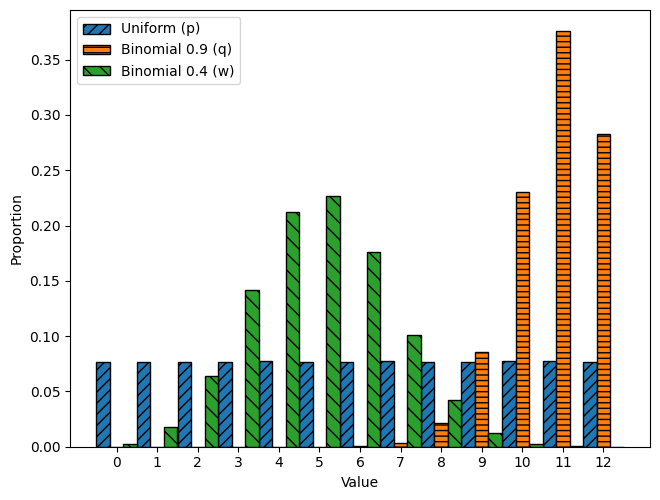

In [12]:
import numpy as np
from scipy.special import rel_entr
import matplotlib.pylab as plt

N = 1000000
p = np.random.randint(0,13,size=N)
p = np.bincount(p)
p = p / p.sum()
print(f"Proportion of each value in p: {p}  (sum: {p.sum()})")
q = np.random.binomial(12,0.9,size=N)
q = np.bincount(q)
q = q / q.sum()
w = np.random.binomial(12,0.4,size=N)
w = np.bincount(w)
w = w / w.sum()
print(f"KL divergence between q and p: {rel_entr(q,p).sum()}")
print(f"KL divergence between w and p: {rel_entr(w,p).sum()}")
print("발산값이 작을 수록 두 분포가 유사하다고 볼 수 있다.")
plt.bar(np.arange(13), p, 0.333, hatch="///", edgecolor='k', label='Uniform (p)')
plt.bar(np.arange(13)+0.333, q, 0.333, hatch="---", edgecolor='k', label='Binomial 0.9 (q)')
plt.bar(np.arange(13)+0.666, w, 0.333, hatch="\\\\", edgecolor='k', label='Binomial 0.4 (w)')
plt.xlabel("Value")
plt.ylabel("Proportion")

# 세 개의 바 중에서 정가운데 바의 위치인 (원래 정수 + 0.333) 지점에 눈금 값을 맞춰 정렬합니다.
plt.xticks(np.arange(13) + 0.333, np.arange(13))

# 범례와 타이트 레이아웃 적용
plt.legend()
plt.tight_layout(pad=0, h_pad=0, w_pad=0)
plt.savefig("kl_divergence.png", dpi=300)
plt.show()



```python
# 1. 실제 기준 확률분포 p 생성 (0부터 12까지 무작위 정수 -> 균등분포 성격)
N = 1000000
p = np.random.randint(0,13,size=N) # 0 ~ 12 사이의 난수 생성
p = np.bincount(p)                 # 각 숫자가 나온 빈도수 카운트 (길이 13)
p = p / p.sum()                    # 합계가 1이 되도록 정규화하여 확률분포화

# 2. 비교 대상 확률분포 q 생성 (시도 횟수 12, 성공 확률 0.9의 이항분포)
q = np.random.binomial(12,0.9,size=N)
q = np.bincount(q)                 # 정수값 빈도수 카운트
q = q / q.sum()                    # 확률분포화

# 3. 비교 대상 확률분포 w 생성 (시도 횟수 12, 성공 확률 0.4의 이항분포)
w = np.random.binomial(12,0.4,size=N)
w = np.bincount(w)                 # 정수값 빈도수 카운트
w = w / w.sum()                    # 확률분포화

# 4. KL 발산값(Kullback-Leibler Divergence) 계산 및 출력
# scipy.special.rel_entr(q, p)는 q와 p 사이의 원소별 상대 엔트로피(KL 발산 성분)를 구합니다.
# 이를 모두 합산(.sum())하여 최종 KL 발산값 계산
print(rel_entr(q,p).sum()) # q 분포가 p 분포와 얼마나 동떨어져 있는지 계산
print(rel_entr(w,p).sum()) # w 분포가 p 분포와 얼마나 동떨어져 있는지 계산

# 5. 세 분포의 비교 시각화 (막대그래프)
plt.bar(np.arange(13),p,0.333,hatch="///",edgecolor='k')       # 균등분포 p (빗금 정방향)
plt.bar(np.arange(13)+0.333,q,0.333,hatch="---",edgecolor='k') # 우측 편향 이항분포 q (가로줄 무늬)
plt.bar(np.arange(13)+0.666,w,0.333,hatch="\\\\",edgecolor='k') # 중앙 근처 이항분포 w (역빗금)
```

#### 코드 작동 방식 요약
- 기준 분포 $p$는 0~12 사이의 비 편향된 고른 평면적인 분포(균등분포)를 가집니다.
- $q$ 분포는 성공 확률이 $0.9$인 이항분포이므로, 오른쪽(자연수 10~12 부근)에 값이 강하게 모여 있는 비대칭 분포를 그립니다.
- $w$ 분포는 성공 확률이 $0.4$로, 그나마 균등분포 $p$의 범위 중간부(4~6 부근)에 골고루 완만하게 퍼져 있습니다.
- 따라서 출력되는 KLD 값은 형태적 결이 더 완만하고 중앙부에 놓인 $w$와 $p$ 쌍의 일치 수준(상대 성능)과 전형적으로 편향된 $q$와 $p$ 쌍의 발산 수준을 수학적 수치(출력값)로 보여주게 됩니다.

---

### 2. 쿨백-라이블러 발산(KLD)이 의미하는 것

KL 발산값 $D_{KL}(P \parallel Q)$는 **"어떤 실제 기준 확률분포 $P$가 존재할 때, 가설 분포 $Q$를 사용해 $P$를 근사적으로 설명하려고 할 때 발생하는 추가적인 정보의 손실(비효율성)"**을 정량화한 수치입니다.

* **수식적 의미**: 
  $$D_{KL}(P \parallel Q) = H(P, Q) - H(P)$$
  - $H(P, Q)$ (교차 엔트로피): 분포 $Q$를 가지고 사태를 예측했을 때 필요로 하는 평균 정보 전달량
  - $H(P)$ (엔트로피): 완전무결한 실제 정답 분포 $P$가 스스로 내포하는 평균 정보 전달량
  - 즉, **"잘못 설계된 가설 $Q$를 선택했기 때문에 지불해야 하는 낭비 정보(비트수)"**가 곧 발산값입니다. 두 분포가 완벽히 같으면 $0$이 되고, 다를수록 $\infty$에 가깝게 값이 커집니다.

---

### 3. AI 및 데이터 경진대회(캐글 등)에서 KLD의 역할

KLD는 단순한 통계 척도를 넘어 현대 딥러닝과 생성형 모델, 경진대회 메트릭에서 핵심적인 시스템 장치로 활용됩니다.

#### ① 생성 모델(VAE, GAN, LLM)의 핵심 엔진
* **변분 오토인코더(VAE, Variational Autoencoder)**: 
  인공지능이 이미지를 그릴 수 있는 잠재 공간(Latent Space)을 학습할 때, 이 잠재 변수들의 무질서한 분포를 안정이 잡힌 '표준정규분포 $\mathcal{N}(0, I)$'에 가깝게 정렬해 주어야 무작위 좌표에서도 그럴듯한 이미지가 생성됩니다. 이때 VAE의 손실 함수에서 잠재 분포와 표준정규분포를 밀착시키기 위해 KLD를 사용합니다.
* **대형 언어 모델(LLM)과 RLHF**:
  챗GPT 같은 LLM을 정렬할 때(PPO, DPO 등의 강화학습), 너무 지나친 파인튜닝으로 인해 모델의 기존 백본 언어 지식이 망가지는 현상(Catastrophic Forgetting)을 막기 위해, 학습 전 원본 언어 모델 분포와 강화학습 진행 중인 모델 분포 사이의 교선 범위를 넓히는 제약 조건(KLD Penalty)으로 작동합니다.

#### ② 데이터 경진대회(캐글 등)에서의 역할
* **Covariate Shift(공변량 변화) 탐색**:
  학습 데이터(Train)의 피처 분포와 평가 데이터(Test)의 피처 분포가 다르면 모델 성능이 폭락합니다. 실력 있는 데이터 과학자들은 Train 데이터와 Test 데이터의 피처 분포(확률밀도함수)를 구한 뒤, 두 세트 간의 **KLD를 계산하여 데이터 이동 및 이질성을 식별**하고 사전에 데이터 불균형 학습을 차단합니다.
* **클래스 불균형에 대응하는 손실 함수 타겟팅**:
  다중 클래스 이미지 세그멘테이션이나 텍스트 라벨 예측 모델 등에서 '소수 클래스 분포'를 정교하게 흉내내야 할 경우, 정답 라벨의 0/1 하드 값 대신 예측된 분포 전체의 거리를 당기는 Soft Label 목적함수로 KLD 손실 함수를 선택해 대회의 상위권을 점유합니다.
* **지식 증류(Knowledge Distillation)**:
  수십 억 파라미터의 초거대 모델(Teacher)이 품은 풍부한 확률 예측 지식을 경량 소형 모델(Student)에 이식시킬 때 쓸 수 있는 수단이 바로 KLD입니다. 소형 모델 예측 결과와 마스터 모델의 전반적인 확률 분포의 부를 KLD를 통해 똑같이 맞춰서 모델을 최적화시킵니다.